# 05. Conditional Probability, Bayes Rule, and Base Rates

Probability becomes genuinely useful when we start conditioning on information. An operations team asks more focused questions than, "How often do severe problems happen?" It asks, "How often do severe problems happen **given** that the triage system fired an alert?" Or, "How often does an alert fire **given** that a ticket really will require executive escalation?" These are different questions, and confusing them is one of the most common sources of analytical error.

We develop conditional probability, Bayes rule, and base-rate reasoning in a seller-support setting. We will simulate a rare-event escalation workflow and study how an automated risk alert should be interpreted. The mathematical ideas are classical, but the decision-science lesson is immediate: an alert is not the same thing as a diagnosis, and the rarity of the event can dominate what a model output really means.


## Learning Objectives

By the end of this lecture, you should be able to:

1. Define conditional probability and explain why probability statements change once context is added.
2. Distinguish $P(A \mid B)$ from $P(B \mid A)$ in practical operational settings.
3. Use Bayes rule to update event probabilities from alert information.
4. Explain why rare-event base rates can make a seemingly strong alert less informative than intuition suggests.
5. Use the law of total probability to decompose overall alert rates into meaningful sources.
6. Translate confusion-matrix quantities into precision, sensitivity, specificity, and review burden.
7. Present a professional recommendation about how an alert should be used in a decision workflow.


In [1]:
# Load the libraries and notebook settings used in the examples below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 24)

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

## 1. Why Conditional Probability Changes the Question

A marginal probability describes uncertainty without additional context. A conditional probability describes uncertainty after some information is known.

If $A$ denotes the event that a support ticket eventually requires executive escalation and $B$ denotes the event that an automated alert fires, then

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

as long as $P(B) > 0$.

This quantity answers a very specific question: among tickets with alerts, what fraction truly escalate? That is not the same as

$$
P(B \mid A) = \frac{P(A \cap B)}{P(A)}
$$

which asks: among tickets that truly escalate, how often does the alert fire?

The first is often called precision or post-alert risk. The second is often called sensitivity or detection rate. In practice, people routinely mix them up.


| Event Symbol | Operational Meaning |
|---|---|
| $E$ | The ticket truly requires executive escalation |
| $H$ | The automated high-risk alert fires |
| $P$ | The seller has a priority contract |
| $F$ | The ticket arrives through the phone channel |
| $S$ | The ticket is high-severity or urgent |


Conditional probability forces us to ask what exactly is being conditioned on. The alert changes the question. Priority status changes the question. Channel changes the question. Each conditioning event gives a more specific probability statement.

This is why conditional probability is foundational for triage, screening, diagnosis, forecasting, and anomaly detection. Real workflows are almost always about probabilities after context is observed, not probabilities in the abstract.

## 2. Simulating a Rare-Event Escalation Workflow

We simulate a support operation in which only a small fraction of tickets truly require executive escalation. The escalation event is rare, but not random in a featureless way. It is more likely when a ticket is urgent, arrives overnight, goes through the phone channel, or comes from a priority-contract seller.

### Dataset and Experiment Design

Each row is a support ticket with observed operational features, a true escalation status, and an automated high-risk alert. The alert is helpful but imperfect. Some true escalations are missed, and some routine tickets are flagged. This mirrors many real decision systems where an alert is a noisy signal, not the same thing as the event we care about.

The experiment compares several questions that are easy to confuse: the probability of escalation among alerted tickets, the probability of an alert among escalated tickets, the share of alerts that consume review capacity, and the impact of rare base rates on alert interpretation. This gives us a practical setting for Bayes rule, natural frequencies, and review-capacity planning.

In [2]:
# Define helper functions and reusable utilities for this section.
rng = np.random.default_rng(2035)

def sigmoid(x):
    """
    Transform a linear score into a probability with the logistic function.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
    
    Returns:
        A scalar or NumPy array containing the logistic transform of `x`, useful for converting linear scores into probabilities.
    
    Idea:
        Convert additive risk drivers into bounded probabilities, allowing synthetic event rates to respond smoothly to covariates.
    """
    return 1.0 / (1.0 + np.exp(-x))


n_tickets = 85_000
seller_tier_levels = np.array(["standard", "growth", "enterprise"])
severity_levels = ["low", "medium", "high", "urgent"]
channel_levels = np.array(["chat", "email", "phone"])

seller_tier = rng.choice(seller_tier_levels, size=n_tickets, p=[0.61, 0.25, 0.14])
priority_contract = (
    (seller_tier == "enterprise")
    | ((seller_tier == "growth") & (rng.random(n_tickets) < 0.36))
).astype(int)

latent_complexity = rng.normal(
    loc=-0.18
    + 0.18 * (seller_tier == "growth")
    + 0.42 * (seller_tier == "enterprise"),
    scale=0.82,
    size=n_tickets,
)
severity_score = latent_complexity + 0.20 * priority_contract + rng.normal(0, 0.90, size=n_tickets)
severity = pd.cut(
    severity_score,
    bins=[-np.inf, -0.55, 0.35, 1.05, np.inf],
    labels=severity_levels,
)
severity = pd.Categorical(severity, categories=severity_levels, ordered=True)

channel_probability_map = {
    "low": [0.64, 0.27, 0.09],
    "medium": [0.46, 0.35, 0.19],
    "high": [0.27, 0.37, 0.36],
    "urgent": [0.10, 0.30, 0.60],
}

channel = np.empty(n_tickets, dtype=object)
for sev, probs in channel_probability_map.items():
    mask = severity == sev
    channel[mask] = rng.choice(channel_levels, size=mask.sum(), p=probs)

overnight_prob = sigmoid(
    -2.15
    + 0.62 * (severity == "urgent").astype(float)
    + 0.24 * (channel == "phone").astype(float)
)
overnight = rng.binomial(1, overnight_prob)

repeat_contact_prob = sigmoid(
    -1.35
    + 0.34 * (severity == "high").astype(float)
    + 0.65 * (severity == "urgent").astype(float)
    + 0.25 * priority_contract
)
repeat_contact = rng.binomial(1, repeat_contact_prob)

queue_load = rng.normal(
    loc=-0.05
    + 0.20 * (severity == "high").astype(float)
    + 0.45 * (severity == "urgent").astype(float)
    + 0.32 * overnight,
    scale=0.78,
    size=n_tickets,
)
queue_load = np.clip(queue_load, -2.2, 3.2)

escalation_logit = (
    -4.60
    + 0.62 * priority_contract
    + 0.52 * (severity == "high").astype(float)
    + 1.18 * (severity == "urgent").astype(float)
    + 0.36 * (channel == "phone").astype(float)
    + 0.44 * overnight
    + 0.40 * repeat_contact
    + 0.42 * queue_load
)
escalation_prob = sigmoid(escalation_logit)
executive_escalation = rng.binomial(1, escalation_prob)

alert_prob = np.where(
    executive_escalation == 1,
    0.77 + 0.06 * priority_contract + 0.05 * (severity == "urgent").astype(float),
    0.03 + 0.03 * priority_contract + 0.02 * (severity == "urgent").astype(float) + 0.015 * (channel == "phone").astype(float),
)
alert_prob = np.clip(alert_prob, 0.01, 0.97)
high_risk_alert = rng.binomial(1, alert_prob)

tickets = pd.DataFrame(
    {
        "seller_tier": seller_tier,
        "priority_contract": priority_contract,
        "severity": severity,
        "channel": channel,
        "overnight": overnight,
        "repeat_contact": repeat_contact,
        "queue_load": queue_load,
        "executive_escalation": executive_escalation,
        "high_risk_alert": high_risk_alert,
    }
)

overview = pd.DataFrame(
    [
        {"quantity": "Tickets in workflow", "value": len(tickets)},
        {"quantity": "Escalation base rate", "value": tickets["executive_escalation"].mean()},
        {"quantity": "Alert rate", "value": tickets["high_risk_alert"].mean()},
        {"quantity": "Priority-contract share", "value": tickets["priority_contract"].mean()},
        {"quantity": "Phone-channel share", "value": (tickets["channel"] == "phone").mean()},
        {"quantity": "Urgent-ticket share", "value": (tickets["severity"] == "urgent").mean()},
    ]
)

smart_display(overview)

,quantity,value
0,Tickets in workflow,85000.000
1,Escalation base rate,0.031
2,Alert rate,0.067
3,Priority-contract share,0.227
4,Phone-channel share,0.267
5,Urgent-ticket share,0.191


The key ingredient here is the base rate. Executive escalation is genuinely rare relative to the full ticket stream. That means even a reasonably strong alert can generate many false alarms simply because there are so many more non-escalation tickets available to be flagged.

This is not a defect of probability theory. It is the whole point of base-rate reasoning. Rare events demand a different kind of intuition than common ones.

## 3. Conditional Probabilities Are Directional

We now compute several conditional probabilities directly from the simulated ticket population. The goal is to make the directional nature of conditioning visible.

For example, compare:

$$
P(E \mid H)
$$

with

$$
P(H \mid E)
$$

These quantities share the same letters, but they answer different questions.


In [3]:
# Build a summary table that supports the interpretation in the surrounding notes.
E = tickets["executive_escalation"] == 1
H = tickets["high_risk_alert"] == 1
P = tickets["priority_contract"] == 1
F = tickets["channel"] == "phone"
S = tickets["severity"].isin(["high", "urgent"])

event_table = pd.DataFrame(
    [
        {"quantity": "P(E): executive escalation", "value": E.mean()},
        {"quantity": "P(H): high-risk alert", "value": H.mean()},
        {"quantity": "P(E | H): escalation given alert", "value": E[H].mean()},
        {"quantity": "P(H | E): alert given escalation", "value": H[E].mean()},
        {"quantity": "P(E | F): escalation given phone", "value": E[F].mean()},
        {"quantity": "P(F | E): phone given escalation", "value": F[E].mean()},
        {"quantity": "P(E | P): escalation given priority", "value": E[P].mean()},
        {"quantity": "P(P | E): priority given escalation", "value": P[E].mean()},
        {"quantity": "P(H | S): alert given high/urgent severity", "value": H[S].mean()},
        {"quantity": "P(S | H): high/urgent severity given alert", "value": S[H].mean()},
    ]
)

smart_display(event_table)


,quantity,value
0,P(E): executive escalation,0.031
1,P(H): high-risk alert,0.067
2,P(E | H): escalation given alert,0.370
3,P(H | E): alert given escalation,0.815
4,P(E | F): escalation given phone,0.058
5,P(F | E): phone given escalation,0.502
6,P(E | P): escalation given priority,0.056
7,P(P | E): priority given escalation,0.418
8,P(H | S): alert given high/urgent severity,0.098
9,P(S | H): high/urgent severity given alert,0.550


The calculation highlights that conditional probabilities are directional. Confusing one direction with the other is a common way to turn a useful signal into an overconfident decision.


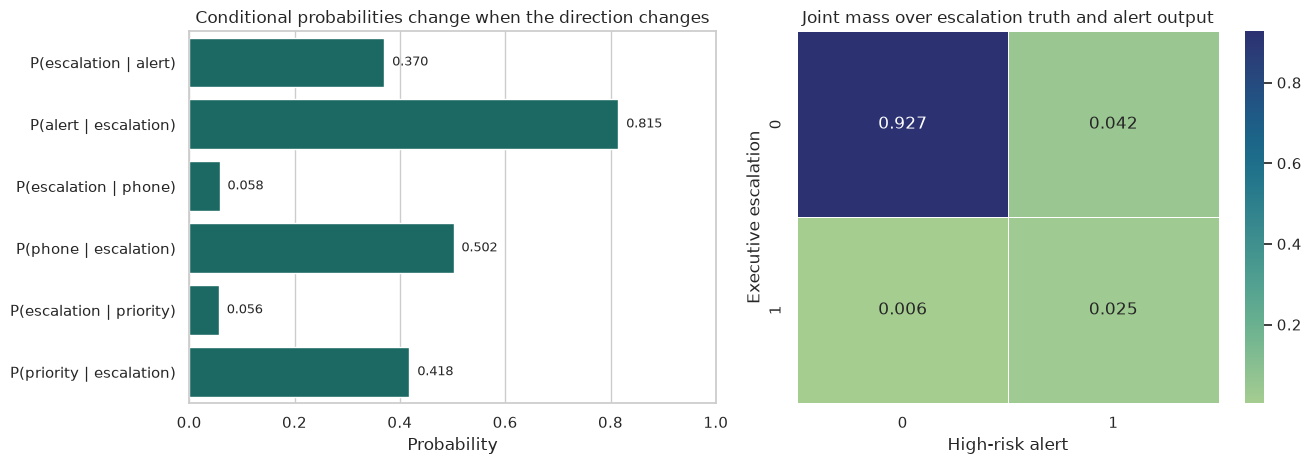

In [4]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
comparison_df = pd.DataFrame(
    {
        "statement": [
            "P(escalation | alert)",
            "P(alert | escalation)",
            "P(escalation | phone)",
            "P(phone | escalation)",
            "P(escalation | priority)",
            "P(priority | escalation)",
        ],
        "probability": [
            E[H].mean(),
            H[E].mean(),
            E[F].mean(),
            F[E].mean(),
            E[P].mean(),
            P[E].mean(),
        ],
    }
)

confusion_probability = pd.crosstab(
    tickets["executive_escalation"],
    tickets["high_risk_alert"],
    normalize="all",
)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

sns.barplot(data=comparison_df, y="statement", x="probability", color="#0f766e", ax=axes[0])
axes[0].set_title("Conditional probabilities change when the direction changes")
axes[0].set_xlabel("Probability")
axes[0].set_ylabel("")
axes[0].set_xlim(0, 1)
for idx, value in enumerate(comparison_df["probability"]):
    axes[0].text(value + 0.015, idx, f"{value:.3f}", va="center", fontsize=9)

sns.heatmap(confusion_probability, annot=True, fmt=".3f", cmap="crest", linewidths=0.5, ax=axes[1])
axes[1].set_title("Joint mass over escalation truth and alert output")
axes[1].set_xlabel("High-risk alert")
axes[1].set_ylabel("Executive escalation")

plt.tight_layout()
plt.show()


The first panel is the one worth slowing down for. Reading the conditional probabilities top-to-bottom makes the directional contrast much easier to see. Typically, $P(H \mid E)$ will be much larger than $P(E \mid H)$. The alert can still be useful. The event is rare, so precision remains constrained by the base rate. Even when an alert catches most truly escalating tickets, the post-alert probability of actual escalation can remain modest because most tickets do not escalate in the first place.

This is the practical reason conditional probability is directional. Swapping the conditioning event changes the denominator, which changes the business meaning.

## 4. Bayes Rule for Alert Interpretation

Bayes rule turns the relationship between these probabilities into a formal identity:

$$
P(E \mid H) = \frac{P(H \mid E) P(E)}{P(H)}
$$

Bayes rule gives the workflow translation.

- $P(E)$ is the base rate of true escalation;
- $P(H \mid E)$ is alert sensitivity;
- $P(H)$ is the overall alert rate;
- $P(E \mid H)$ is the post-alert probability that decision-makers actually care about.


In [5]:
# Build a summary table that supports the interpretation in the surrounding notes.
tp = ((E) & (H)).sum()
fp = ((~E) & (H)).sum()
fn = ((E) & (~H)).sum()
tn = ((~E) & (~H)).sum()

prevalence = E.mean()
alert_rate = H.mean()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
false_positive_rate = 1 - specificity
precision = tp / (tp + fp)
npv = tn / (tn + fn)
bayes_precision = sensitivity * prevalence / alert_rate

metric_table = pd.DataFrame(
    [
        {"metric": "Base rate P(E)", "value": prevalence},
        {"metric": "Alert rate P(H)", "value": alert_rate},
        {"metric": "Sensitivity P(H | E)", "value": sensitivity},
        {"metric": "Specificity P(H^c | E^c)", "value": specificity},
        {"metric": "False positive rate P(H | E^c)", "value": false_positive_rate},
        {"metric": "Precision P(E | H)", "value": precision},
        {"metric": "Negative predictive value P(E^c | H^c)", "value": npv},
        {"metric": "Bayes-rule reconstruction of P(E | H)", "value": bayes_precision},
    ]
)

smart_display(metric_table)


,metric,value
0,Base rate P(E),0.031
1,Alert rate P(H),0.067
2,Sensitivity P(H | E),0.815
3,Specificity P(H^c | E^c),0.956
4,False positive rate P(H | E^c),0.044
5,Precision P(E | H),0.370
6,Negative predictive value P(E^c | H^c),0.994
7,Bayes-rule reconstruction of P(E | H),0.370


The calculation highlights that conditional probabilities are directional. Confusing one direction with the other is a common way to turn a useful signal into an overconfident decision.


,quantity,value
0,Direct precision P(E | H),0.370
1,Bayes numerator P(H | E)P(E),0.025
2,Overall alert rate P(H),0.067
3,Bayes precision [P(H | E)P(E)] / P(H),0.370


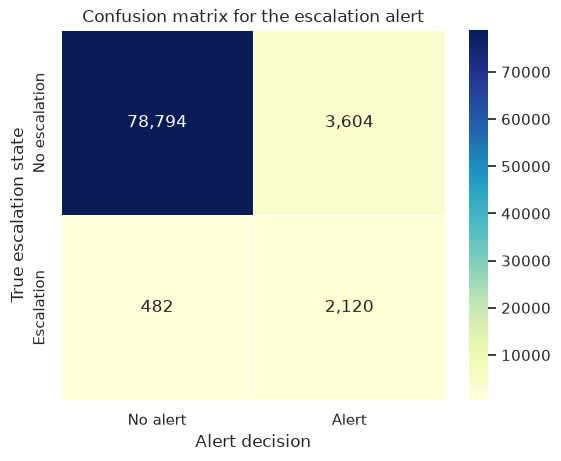

In [6]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
bayes_identity_table = pd.DataFrame(
    [
        {"quantity": "Direct precision P(E | H)", "value": precision},
        {"quantity": "Bayes numerator P(H | E)P(E)", "value": sensitivity * prevalence},
        {"quantity": "Overall alert rate P(H)", "value": alert_rate},
        {"quantity": "Bayes precision [P(H | E)P(E)] / P(H)", "value": bayes_precision},
    ]
)
smart_display(bayes_identity_table)

confusion_counts = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["No escalation", "Escalation"],
    columns=["No alert", "Alert"],
)

plt.figure(figsize=(6.2, 4.8))
sns.heatmap(confusion_counts, annot=True, fmt=",", cmap="YlGnBu", linewidths=0.5)
plt.title("Confusion matrix for the escalation alert")
plt.xlabel("Alert decision")
plt.ylabel("True escalation state")
plt.show()


The Bayes identity table is doing something very practical. It reconstructs post-alert risk from three pieces: how rare true escalation is, how often the alert catches it, and how often the alert fires overall. When the event is rare, the denominator $P(H)$ can still be inflated by false alarms even if sensitivity is respectable.

This is why a strong alert in a rare-event environment can still have only moderate precision. A model may be good enough for triage while still being far from definitive.

## 5. The Law of Total Probability and Where Alerts Come From

Bayes rule works hand in hand with the law of total probability:

$$
P(H) = P(H \mid E)P(E) + P(H \mid E^c)P(E^c)
$$

This decomposition says that the total alert rate comes from two sources:

1. true escalations that were correctly alerted;
2. non-escalation tickets that were alerted anyway.

In rare-event settings, the second component can be surprisingly large.


,quantity,value
0,Direct alert rate P(H),0.067
1,True-alert contribution P(H | E)P(E),0.025
2,False-alert contribution P(H | E^c)P(E^c),0.042
3,Reconstructed alert rate,0.067


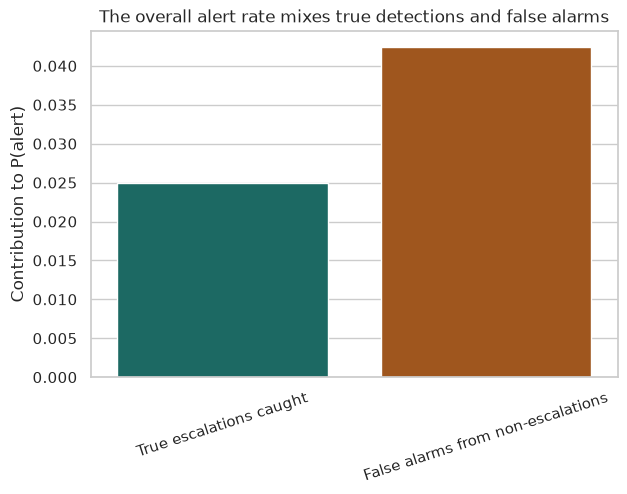

In [7]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
true_alert_contribution = sensitivity * prevalence
false_alert_contribution = false_positive_rate * (1 - prevalence)

decomposition_table = pd.DataFrame(
    [
        {"quantity": "Direct alert rate P(H)", "value": alert_rate},
        {"quantity": "True-alert contribution P(H | E)P(E)", "value": true_alert_contribution},
        {"quantity": "False-alert contribution P(H | E^c)P(E^c)", "value": false_alert_contribution},
        {"quantity": "Reconstructed alert rate", "value": true_alert_contribution + false_alert_contribution},
    ]
)
smart_display(decomposition_table)

contrib_df = pd.DataFrame(
    {
        "source": ["True escalations caught", "False alarms from non-escalations"],
        "probability_mass": [true_alert_contribution, false_alert_contribution],
    }
)

plt.figure(figsize=(6.8, 4.5))
sns.barplot(data=contrib_df, x="source", y="probability_mass", hue="source", palette=["#0f766e", "#b45309"], legend=False)
plt.title("The overall alert rate mixes true detections and false alarms")
plt.xlabel("")
plt.ylabel("Contribution to P(alert)")
plt.xticks(rotation=18)
plt.show()


This decomposition is often where intuition resets. People see that the alert is fairly sensitive and conclude that an alert must imply high risk. But the law of total probability reminds us that overall alert volume also includes false positives from the far larger non-escalation population.

That is the base-rate story in one line: a small false-positive rate applied to a very large background population can still create substantial alert volume.

## 6. Base Rates and Why Rare Events Are Hard

To see the base-rate effect more clearly, we now ask a counterfactual question: what would the post-alert probability of true escalation be if the alert kept the same sensitivity and specificity, but the event prevalence changed?

Bayes rule tells us the answer. For fixed sensitivity and specificity, precision depends strongly on prevalence.


,prevalence,ppv_at_empirical_sensitivity_and_0.90_specificity,ppv_at_empirical_sensitivity_and_0.95_specificity,ppv_at_empirical_sensitivity_and_0.98_specificity
0,0.005,0.039,0.076,0.170
1,0.010,0.076,0.141,0.292
2,0.020,0.143,0.250,0.454
3,0.050,0.300,0.462,0.682
4,0.100,0.475,0.644,0.819
5,0.200,0.671,0.803,0.911


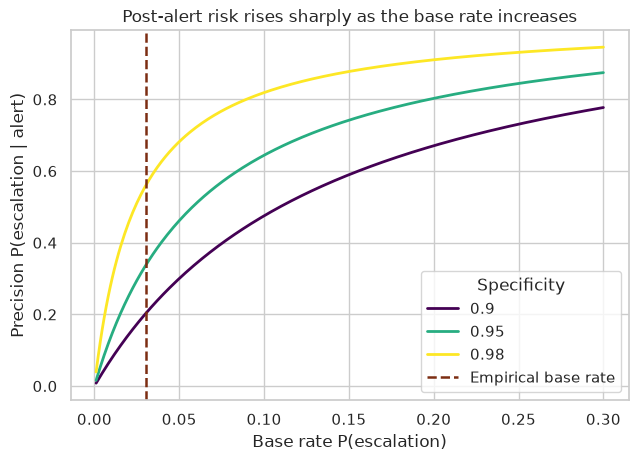

In [8]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
prevalence_grid = np.linspace(0.001, 0.30, 250)
specificity_levels = [0.90, 0.95, 0.98]
sensitivity_fixed = sensitivity

ppv_rows = []
for spec in specificity_levels:
    for prev in prevalence_grid:
        ppv = (sensitivity_fixed * prev) / ((sensitivity_fixed * prev) + (1 - spec) * (1 - prev))
        ppv_rows.append(
            {
                "prevalence": prev,
                "specificity": spec,
                "ppv": ppv,
            }
        )

ppv_curve = pd.DataFrame(ppv_rows)

discrete_prev = np.array([0.005, 0.010, 0.020, 0.050, 0.100, 0.200])
ppv_table = pd.DataFrame(
    {
        "prevalence": discrete_prev,
        "ppv_at_empirical_sensitivity_and_0.90_specificity": [
            (sensitivity_fixed * p) / ((sensitivity_fixed * p) + 0.10 * (1 - p)) for p in discrete_prev
        ],
        "ppv_at_empirical_sensitivity_and_0.95_specificity": [
            (sensitivity_fixed * p) / ((sensitivity_fixed * p) + 0.05 * (1 - p)) for p in discrete_prev
        ],
        "ppv_at_empirical_sensitivity_and_0.98_specificity": [
            (sensitivity_fixed * p) / ((sensitivity_fixed * p) + 0.02 * (1 - p)) for p in discrete_prev
        ],
    }
)
smart_display(ppv_table)

plt.figure(figsize=(7.2, 4.8))
sns.lineplot(data=ppv_curve, x="prevalence", y="ppv", hue="specificity", palette="viridis", linewidth=2)
plt.axvline(prevalence, color="#7c2d12", linestyle="--", linewidth=1.8, label="Empirical base rate")
plt.title("Post-alert risk rises sharply as the base rate increases")
plt.xlabel("Base rate P(escalation)")
plt.ylabel("Precision P(escalation | alert)")
plt.legend(title="Specificity")
plt.show()


This plot is the cleanest visual explanation of base-rate dependence in the notebook. When the event is extremely rare, precision remains limited unless specificity is very high. As prevalence increases, the same alert becomes much more trustworthy.

This is why the same model can look impressive in one environment and frustrating in another. The model and the event ecology both matter.

## 7. Natural Frequencies and Review Capacity

One of the easiest ways to make Bayesian reasoning more intuitive is to convert abstract probabilities into natural frequencies. A more operational phrasing is, "Out of 10,000 tickets, about 310 alerted tickets are true escalations and about 690 alerted tickets are false alarms."

This is especially useful when an operations team has finite manual-review capacity.


In [9]:
# Build a summary table that supports the interpretation in the surrounding notes.
scale = 10_000 / len(tickets)

natural_frequency_table = pd.DataFrame(
    [
        {"count_per_10000_tickets": round(tp * scale), "outcome": "True escalations correctly alerted"},
        {"count_per_10000_tickets": round(fp * scale), "outcome": "Non-escalation tickets falsely alerted"},
        {"count_per_10000_tickets": round(fn * scale), "outcome": "Escalations missed by the alert"},
        {"count_per_10000_tickets": round(tn * scale), "outcome": "Non-escalation tickets correctly ignored"},
    ]
)
smart_display(natural_frequency_table)

segment_summary = (
    tickets.assign(segment=np.where(tickets["priority_contract"] == 1, "Priority sellers", "Non-priority sellers"))
    .groupby("segment", observed=True)
    .apply(
        lambda df: pd.Series(
            {
                "tickets": len(df),
                "escalation_rate": df["executive_escalation"].mean(),
                "alert_rate": df["high_risk_alert"].mean(),
                "precision_among_alerts": df.loc[df["high_risk_alert"] == 1, "executive_escalation"].mean(),
                "sensitivity_within_segment": (
                    df.loc[df["executive_escalation"] == 1, "high_risk_alert"].mean()
                ),
            }
        )
    )
    .reset_index()
)
smart_display(segment_summary)


,count_per_10000_tickets,outcome
0,249,True escalations correctly alerted
1,424,Non-escalation tickets falsely alerted
2,57,Escalations missed by the alert
3,9270,Non-escalation tickets correctly ignored


,segment,tickets,escalation_rate,alert_rate,precision_among_alerts,sensitivity_within_segment
0,Non-priority sellers,65678.000,0.023,0.053,0.338,0.783
1,Priority sellers,19322.000,0.056,0.115,0.421,0.859


The calculation highlights that conditional probabilities are directional. Confusing one direction with the other is a common way to turn a useful signal into an overconfident decision.


In [10]:
# Build a summary table that supports the interpretation in the surrounding notes.
minutes_per_review = 12
alerts_per_10000 = round((tp + fp) * scale)
review_hours_per_10000 = alerts_per_10000 * minutes_per_review / 60
priority_precision = segment_summary.loc[segment_summary["segment"] == "Priority sellers", "precision_among_alerts"].iloc[0]
nonpriority_precision = segment_summary.loc[segment_summary["segment"] == "Non-priority sellers", "precision_among_alerts"].iloc[0]

recommendation = (
    f"Use the alert as a triage signal with human or rule-based review before escalation. At the current base rate, about {alerts_per_10000} tickets per 10,000 would be reviewed, costing roughly {review_hours_per_10000:.1f} analyst-hours. Precision is meaningfully higher for priority sellers than for non-priority sellers, so a layered review policy should give priority-alerted tickets the fastest human follow-up."
    if priority_precision > nonpriority_precision
    else f"Use the alert as a triage signal with human or rule-based review before escalation. At the current base rate, about {alerts_per_10000} tickets per 10,000 would be reviewed, costing roughly {review_hours_per_10000:.1f} analyst-hours, and the alert should be paired with additional context before any high-cost intervention is triggered."
)

smart_display(recommendation)


'Use the alert as a triage signal with human or rule-based review before escalation. At the current base rate, about 673 tickets per 10,000 would be reviewed, costing roughly 134.6 analyst-hours. Precision is meaningfully higher for priority sellers than for non-priority sellers, so a layered review policy should give priority-alerted tickets the fastest human follow-up.'

The natural-frequency table and segment summary bring the mathematics back to workflow design. Decision-makers do not act on Bayes rule in the abstract. They act on review queues, analyst-hours, false-positive burden, and service-level priorities.

The operational lesson is clear. rare-event alerts are often most useful for prioritization, routing, and staged review. Standalone event confirmation requires more evidence.

## Wrap-Up

We introduced the core conditional-probability ideas that make alerting systems interpretable:

1. Conditional probabilities are directional and change when the conditioning event changes.
2. $P(E \mid H)$ and $P(H \mid E)$ are not interchangeable.
3. Bayes rule translates base rate, sensitivity, and alert volume into post-alert risk.
4. The law of total probability explains where overall alert rates come from.
5. Rare-event environments can produce modest precision even for useful alerts.
6. Natural frequencies often communicate Bayesian ideas more clearly than raw probabilities alone.
7. Good decision practice treats alerts as workflow inputs, not as automatic truth statements.

The next notebook will build on this foundation by turning probability language into sampling, measurement, and data-collection concerns where bias enters before any model is even fit.


## References

- Gigerenzer, G., & Hoffrage, U. (1995). *How to improve Bayesian reasoning without instruction: Frequency formats*. *Psychological Review*, 102(4), 684-704. [https://doi.org/10.1037/0033-295X.102.4.684](https://doi.org/10.1037/0033-295X.102.4.684)
- Peterson, C. R., & Beach, L. R. (1967). *Man as an intuitive statistician*. *Psychological Bulletin*, 68(1), 29-46. [https://doi.org/10.1037/h0024722](https://doi.org/10.1037/h0024722)
- Spiegelhalter, D., Pearson, M., & Short, I. (2011). *Visualizing uncertainty about the future*. *Science*, 333(6048), 1393-1400. [https://doi.org/10.1126/science.1191181](https://doi.org/10.1126/science.1191181)
- Tversky, A., & Kahneman, D. (1974). *Judgment under uncertainty: Heuristics and biases*. *Science*, 185(4157), 1124-1131. [https://doi.org/10.1126/science.185.4157.1124](https://doi.org/10.1126/science.185.4157.1124)
